/tmp/ipython-input-459/3569094816.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2018-01-01")[["Close"]]
[*********************100%***********************]  1 of 1 completed


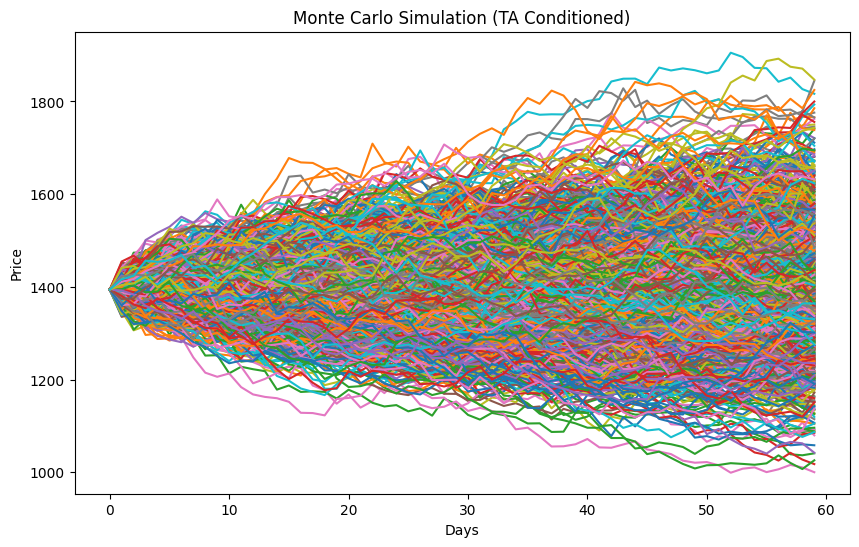

Current Price: 1393.9
Drift Used: 9.5e-05
Volatility Used: 0.013313

--- Probability Outputs ---
Probability of Breakout: 10.1 %
Probability of +10% Gain: 17.9 %
Probability of -5% Loss: 30.9 %
5% VaR Price Level: 1182.32


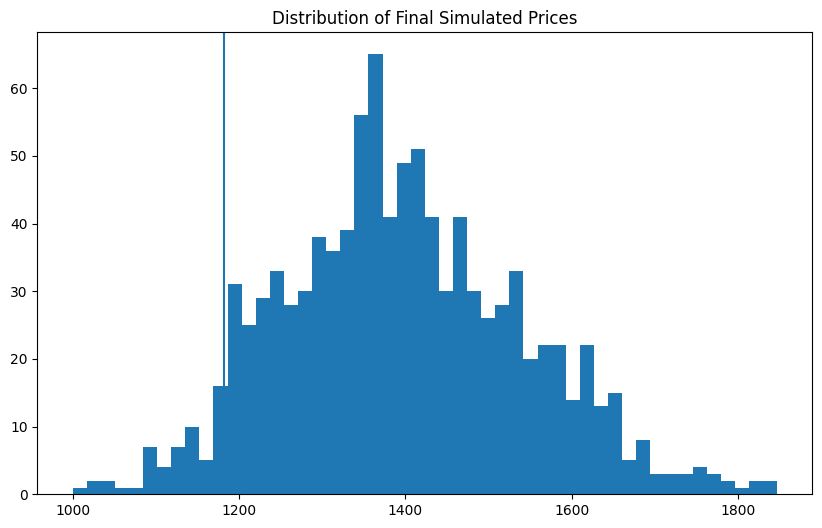

In [3]:
# ============================================
# TECHNICAL ANALYSIS + MONTE CARLO SIMULATION
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

# -----------------------------
# 1. DOWNLOAD DATA
# -----------------------------
ticker = "RELIANCE.NS"
data = yf.download(ticker, start="2018-01-01")[["Close"]]
data.dropna(inplace=True)

# -----------------------------
# 2. TECHNICAL INDICATORS
# -----------------------------

# Moving Averages
data["MA50"] = data["Close"].rolling(50).mean()
data["MA200"] = data["Close"].rolling(200).mean()

# Log Returns
data["Log_Return"] = np.log(data["Close"] / data["Close"].shift(1))

# Rolling Volatility (30 days)
data["Rolling_Vol"] = data["Log_Return"].rolling(30).std()

# RSI (14-day)
delta = data["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
data["RSI"] = 100 - (100 / (1 + rs))

data.dropna(inplace=True)

# -----------------------------
# 3. REGIME-BASED DRIFT
# -----------------------------
latest = data.iloc[-1]

drift = data["Log_Return"].mean()

# Trend conditioning
if latest["Close"].item() > latest["MA200"].item():
    drift += 0.0005  # bullish bias
else:
    drift -= 0.0005  # bearish bias

# RSI conditioning
if latest["RSI"].item() < 30:
    drift += 0.001   # oversold bounce
elif latest["RSI"].item() > 70:
    drift -= 0.001   # overbought correction

# Volatility from rolling window
sigma = latest["Rolling_Vol"].item()

# -----------------------------
# 4. MONTE CARLO SETTINGS
# -----------------------------
T = 60              # 60 trading days
simulations = 1000
S0 = latest["Close"].item()

# -----------------------------
# 5. MONTE CARLO SIMULATION
# -----------------------------
Z = np.random.standard_normal((T, simulations))

daily_returns = np.exp(
    (drift - 0.5 * sigma**2) +
    sigma * Z
)

price_paths = np.zeros_like(daily_returns)
price_paths[0] = S0

for t in range(1, T):
    price_paths[t] = price_paths[t-1] * daily_returns[t]

# -----------------------------
# 6. PLOT SIMULATION PATHS
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(price_paths)
plt.title("Monte Carlo Simulation (TA Conditioned)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

# -----------------------------
# 7. PROBABILITY ANALYSIS
# -----------------------------

final_prices = price_paths[-1]

# Breakout Probability (50-day high)
resistance = data["Close"].rolling(50).max().iloc[-1]
prob_breakout = np.mean(final_prices > resistance.item())

# Target +10%
target = S0 * 1.10
prob_target = np.mean(final_prices > target)

# Stop Loss -5%
stop = S0 * 0.95
prob_stop = np.mean(final_prices < stop)

# 5% VaR
var_5 = np.percentile(final_prices, 5)

# -----------------------------
# 8. PRINT RESULTS
# -----------------------------
print("Current Price:", round(S0,2))
print("Drift Used:", round(drift,6))
print("Volatility Used:", round(sigma,6))
print("\n--- Probability Outputs ---")
print("Probability of Breakout:", round(prob_breakout*100,2), "%")
print("Probability of +10% Gain:", round(prob_target*100,2), "%")
print("Probability of -5% Loss:", round(prob_stop*100,2), "%")
print("5% VaR Price Level:", round(var_5,2))

# -----------------------------
# 9. HISTOGRAM OF FINAL PRICES
# -----------------------------
plt.figure(figsize=(10,6))
plt.hist(final_prices, bins=50)
plt.axvline(var_5)
plt.title("Distribution of Final Simulated Prices")
plt.show()

Expected Shortfall (CVaR)

In [4]:
# -----------------------------
# EXPECTED SHORTFALL (5%)
# -----------------------------

alpha = 5

var_5 = np.percentile(final_prices, alpha)

# Tail losses
tail_losses = final_prices[final_prices <= var_5]

expected_shortfall = np.mean(tail_losses)

print("\n--- Tail Risk Measures ---")
print("5% VaR Price Level:", round(var_5,2))
print("5% Expected Shortfall Price:", round(expected_shortfall,2))

# Convert to percentage loss
var_loss_pct = (S0 - var_5) / S0 * 100
es_loss_pct = (S0 - expected_shortfall) / S0 * 100

print("VaR Loss (%):", round(var_loss_pct,2), "%")
print("Expected Shortfall Loss (%):", round(es_loss_pct,2), "%")


--- Tail Risk Measures ---
5% VaR Price Level: 1182.32
5% Expected Shortfall Price: 1125.37
VaR Loss (%): 15.18 %
Expected Shortfall Loss (%): 19.26 %


Compute Expected Gain & Loss

Risk-Reward= Average loss beyond stop / Average gain beyond target
	​


In [5]:
# -----------------------------
# RISK-REWARD ANALYSIS
# -----------------------------

# Expected upside (conditional)
upside_prices = final_prices[final_prices > target]
downside_prices = final_prices[final_prices < stop]

if len(upside_prices) > 0:
    expected_upside = np.mean(upside_prices) - S0
else:
    expected_upside = 0

if len(downside_prices) > 0:
    expected_downside = S0 - np.mean(downside_prices)
else:
    expected_downside = 0

# Probability-adjusted expected return
expected_return = np.mean(final_prices - S0)

print("\n--- Risk Reward Metrics ---")
print("Expected Return (₹):", round(expected_return,2))
print("Expected Upside beyond +10%:", round(expected_upside,2))
print("Expected Downside beyond -5%:", round(expected_downside,2))

if expected_downside != 0:
    risk_reward_ratio = expected_upside / expected_downside
    print("Risk-Reward Ratio:", round(risk_reward_ratio,2))


--- Risk Reward Metrics ---
Expected Return (₹): 2.98
Expected Upside beyond +10%: 225.34
Expected Downside beyond -5%: 157.95
Risk-Reward Ratio: 1.43
